# Bank Loan Analysis Report

### Import libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import plotly.express as px

In [23]:
df= pd.read_excel("C:/Users/pyary/OneDrive/Desktop/New folder/financial_loan.xlsx")

In [24]:
df.head()  

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [25]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### Metadata of data

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

### Datatypes

In [10]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [11]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Appications

In [15]:
total_loan_application= df['id'].count()
print("Total loan applications:", total_loan_application)

Total loan applications: 38576


### Month to Date Total Loan applications calculation

In [14]:
latest_issue_date= df['issue_date'].max()
print("Latest Issue Date", latest_issue_date)

Latest Issue Date 2021-12-12 00:00:00


In [17]:
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
print("Year and Month:",latest_year,latest_month )

Year and Month: 2021 12


In [20]:
 ## Filtering the month to date 
mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_application = mtd_date['id'].count()

print(f" MTD loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_application}")


 MTF loan Applications (for December 2021): 4314


### Total Funded Amount

In [27]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD - Total Funded Amount

In [50]:
latest_issue_date= df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_date['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000

print(f"Mtd of total funded amount of {latest_issue_date.strftime('%B %Y')}:"  "${:.2f}M".format(mtd_total_funded_amount_millions))


Mtd of total funded amount of December 2021:$53.98M


### Total Amount Received

In [18]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received/1000000
print("Total amount_received : ${:.2f}M".format(total_amount_received_millions))


Total amount_received : $473.07M


### MTD of Total Amount Received

In [54]:
latest_issue_date= df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_date['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received/1000000

print(f"Mtd of total amount_received for {latest_issue_date.strftime('%B %Y')}:"  "${:.2f}M".format(mtd_total_amount_received_millions))


Mtd of total amount_received for December 2021:$58.07M


### Average interest rate

In [60]:
average_interest_rate = df['int_rate'].mean()*100
print("Average interest rate: {:.2f}%".format(average_interest_rate))

Average interest rate: 12.05%


### Average Debt to interest rate

In [61]:
average_dti = df['dti'].mean()*100
print("Average debt interest rate: {:.2f}%".format(average_dti))

Average debt interest rate: 13.33%


### Good Loan Metrics

In [19]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount/1000000
good_loan_received_millions = good_loan_received/1000000

good_loan_percentage = (good_loan_applications/total_loan_applications)*100

print("Good loan Applications:", good_loan_applications)
print("Good loan funded Applications (in millions):${:.2f}M".format(good_loan_funded_amount_millions))
print("Good loan Received (in millions):${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good loan Applications: {:.2f}%".format(good_loan_percentage))


Good loan Applications: 33243
Good loan funded Applications (in millions):$370.22M
Good loan Received (in millions):$435.79M
Percentage of Good loan Applications: 86.18%


### Bad Loan Metrics

In [20]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount =bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount/1000000
bad_loan_received_millions = bad_loan_received/1000000

bad_loan_percentage = (bad_loan_applications/total_loan_applications)*100

print("bad loan Applications:", bad_loan_applications)
print("bad loan Applications (in millions):${:.2f}M".format(bad_loan_funded_amount_millions))
print("bad loan Received (in millions):${:.2f}M".format(bad_loan_received_millions))
print("Percentage of bad loan Applications: {:.2f}%".format(bad_loan_percentage))

bad loan Applications: 5333
bad loan Applications (in millions):$65.53M
bad loan Received (in millions):$37.28M
Percentage of bad loan Applications: 13.82%


### Monthly trends by issue date for Total Funded Amount

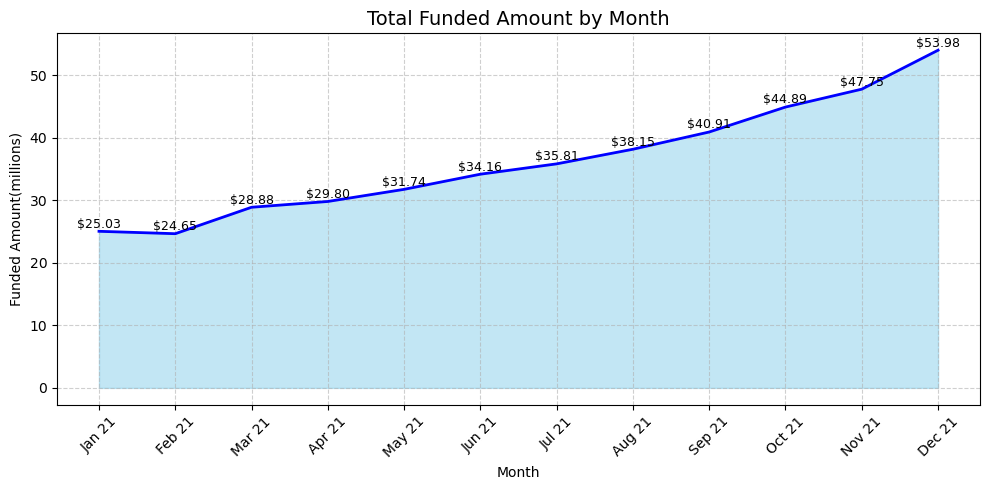

In [21]:
monthly_funded =(df.sort_values('issue_date')
                .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %y'))
                .groupby('month_name', sort = False)['loan_amount']
                .sum()
                .div(1000000)
                .reset_index(name = 'loan_amount_millions'))
plt.figure(figsize =(10,5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color ='skyblue', alpha = 0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color ='blue', linewidth = 2)

for _, row in monthly_funded.iterrows():
  plt.text(row['month_name'], row['loan_amount_millions']+0.1,
              f"${row['loan_amount_millions']:.2f}",
              ha = 'center', va = 'bottom', fontsize = 9, rotation =0,color = 'black')

plt.title('Total Funded Amount by Month',fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Funded Amount(millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels = monthly_funded['month_name'], rotation = 45)
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()





### Monthly trends by issue date for Total Amount Received

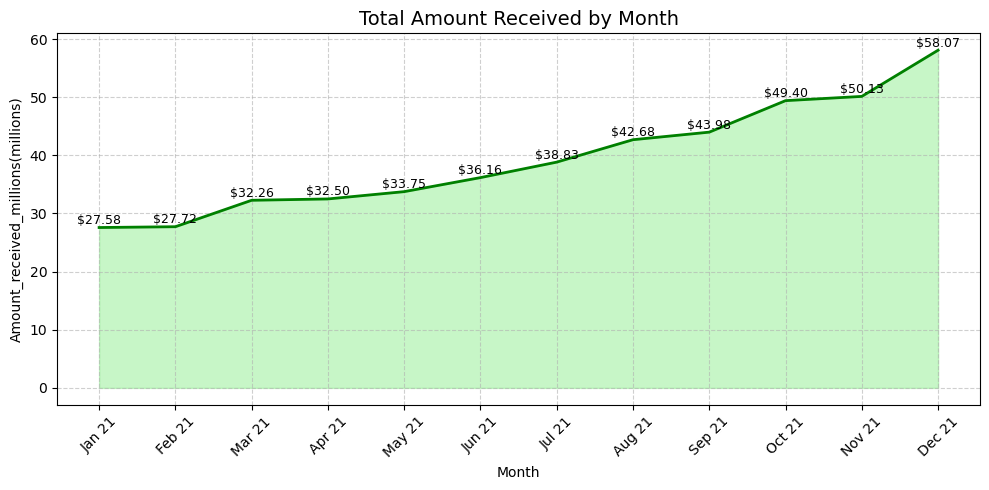

In [34]:
monthly_received = (df.sort_values('issue_date')
                .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %y'))
                .groupby('month_name', sort = False)['total_payment']
                .sum()
                .div(1000000)
                .reset_index(name = 'amount_received_millions'))
plt.figure(figsize =(10,5))
plt.fill_between(monthly_received['month_name'], monthly_received['amount_received_millions'], color ='lightgreen', alpha = 0.5)
plt.plot(monthly_received['month_name'], monthly_received['amount_received_millions'], color ='green', linewidth = 2)

for _, row in monthly_received.iterrows():
  plt.text(row['month_name'], row['amount_received_millions']+0.1, f"${row['amount_received_millions']:.2f}",
              ha = 'center', va = 'bottom', fontsize = 9, rotation =0,color = 'black')

plt.title('Total Amount Received by Month',fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Amount_received_millions(millions)')
plt.xticks(ticks = range(len(monthly_received)), labels = monthly_received['month_name'], rotation = 45)
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()

### Monthly trends by issue date for Total Loan Applications

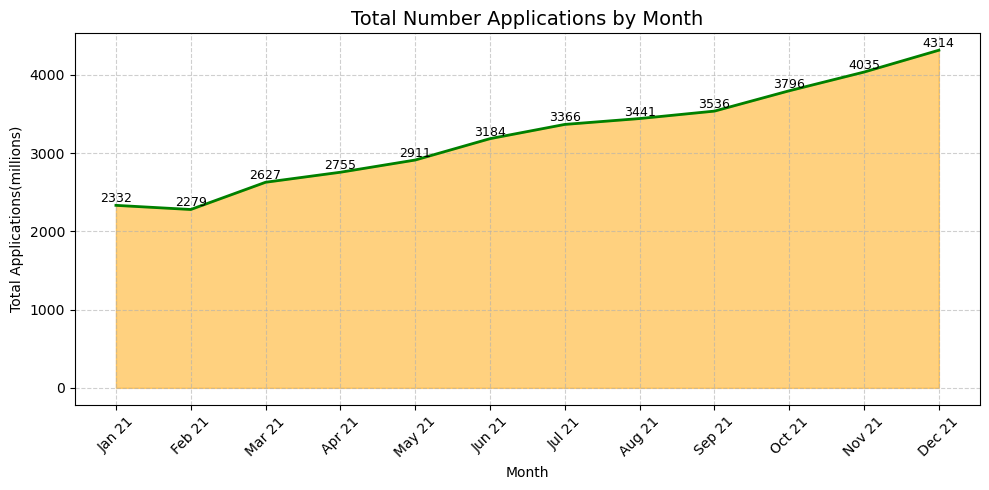

In [44]:
monthly_loan_applications = (df.sort_values('issue_date')
                .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %y'))
                .groupby('month_name', sort = False)['id']
                .count()
                .reset_index(name = 'total_loan_applications'))

plt.figure(figsize =(10,5))
plt.fill_between(monthly_loan_applications['month_name'], monthly_loan_applications['total_loan_applications'], color ='orange', alpha = 0.5)
plt.plot(monthly_loan_applications['month_name'], monthly_loan_applications['total_loan_applications'], color ='green', linewidth = 2)

for i, row in monthly_loan_applications.iterrows():
  plt.text(i, row['total_loan_applications']+.5,
              f"{row['total_loan_applications']}",
              ha = 'center', va = 'bottom', fontsize = 9, rotation =0,color = 'black')

plt.title('Total Number Applications by Month',fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Total Applications(millions)')
plt.xticks(ticks = range(len(monthly_loan_applications)), labels = monthly_loan_applications['month_name'], rotation = 45)
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

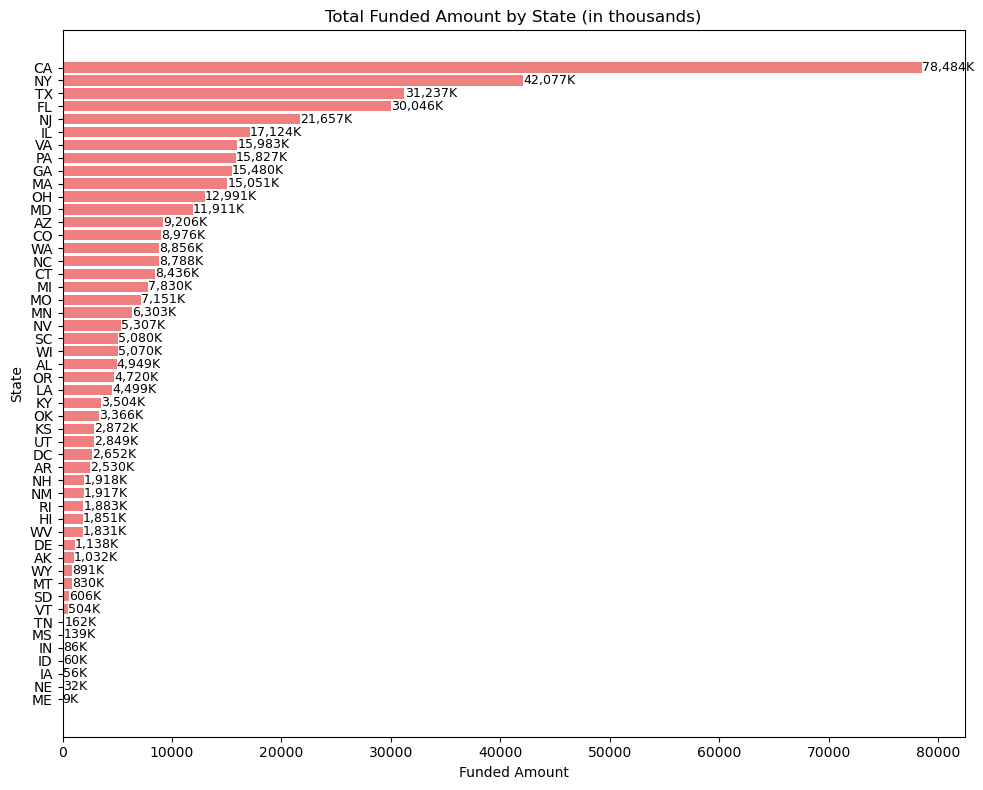

In [50]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding/1000

plt.figure(figsize = (10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va = 'center', fontsize = 9)

plt.title('Total Funded Amount by State (in thousands)')
plt.xlabel('Funded Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()


### Regional Analysis by State for Total Amount Received

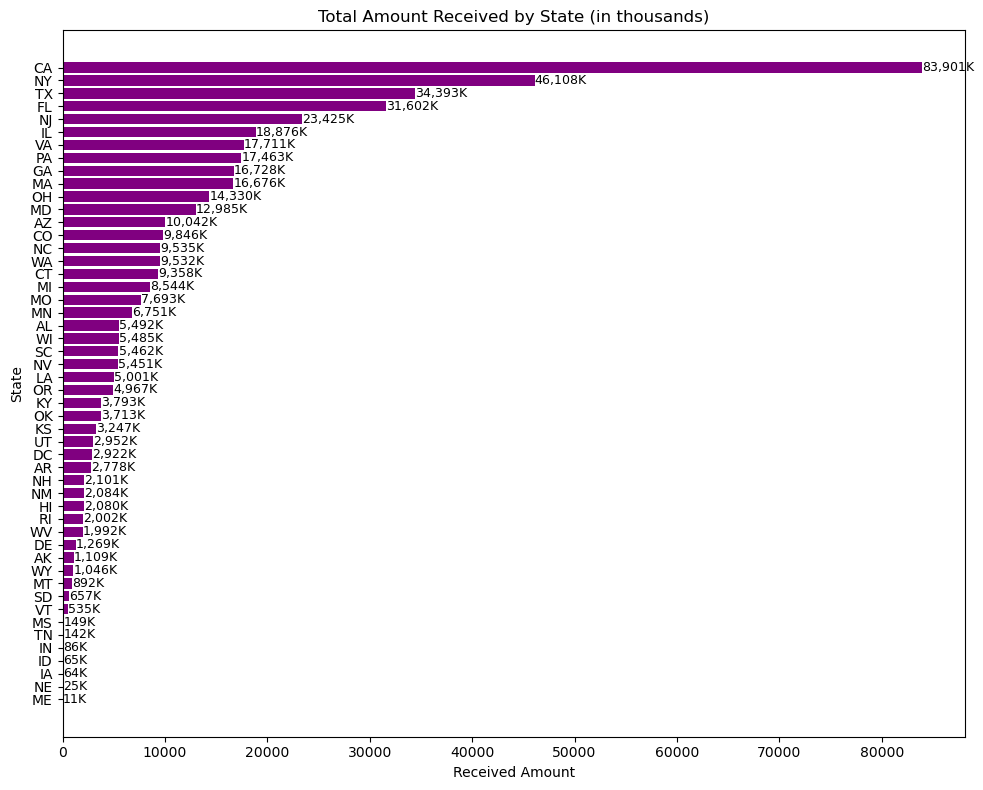

In [51]:
state_amount_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_amount_received_thousands = state_amount_received/1000

plt.figure(figsize = (10,8))
bars = plt.barh(state_amount_received_thousands.index, state_amount_received_thousands.values, color = 'purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va = 'center', fontsize = 9)

plt.title('Total Amount Received by State (in thousands)')
plt.xlabel('Received Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Loan Applications

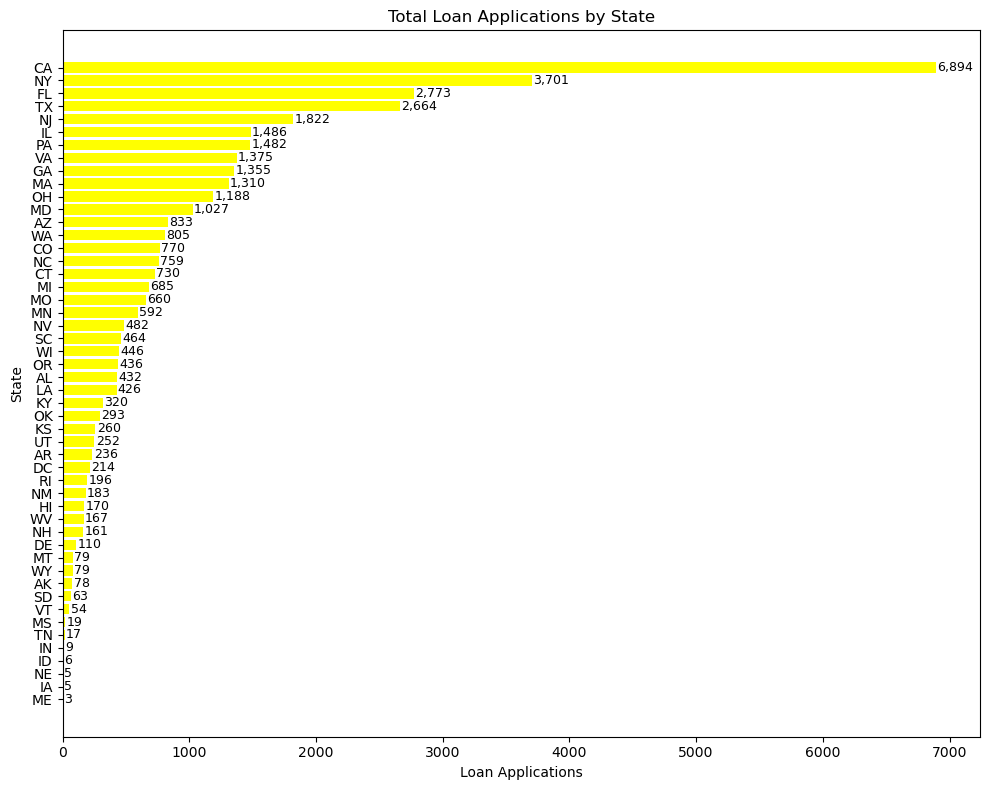

In [57]:
state_total_applications = df.groupby('address_state')['id'].count().sort_values(ascending=True)
##state_amount_received_thousands = state_amount_received/1000

plt.figure(figsize = (10,8))
bars = plt.barh(state_total_applications.index, state_total_applications.values, color = 'yellow')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}', va = 'center', fontsize = 9)

plt.title('Total Loan Applications by State')
plt.xlabel('Loan Applications')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Long Term Analysis for Total Funded Amount

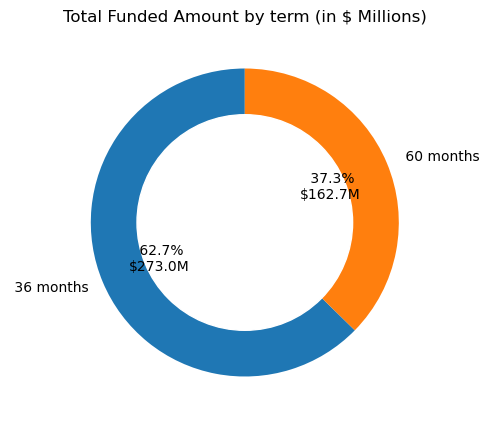

In [60]:
term_funded_amount_millions = df.groupby('term')['loan_amount'].sum()/1000000

plt.figure(figsize = (5,5))
plt.pie(
    term_funded_amount_millions,
    labels = term_funded_amount_millions.index,
    autopct = lambda p: f" {p:.1f}%\n${p*sum(term_funded_amount_millions)/100:.1f}M",
    startangle = 90,
    wedgeprops = {'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, color = 'white'))
plt.title('Total Funded Amount by term (in $ Millions)')
plt.show()

### Long Term Analysis for Total Amount Received

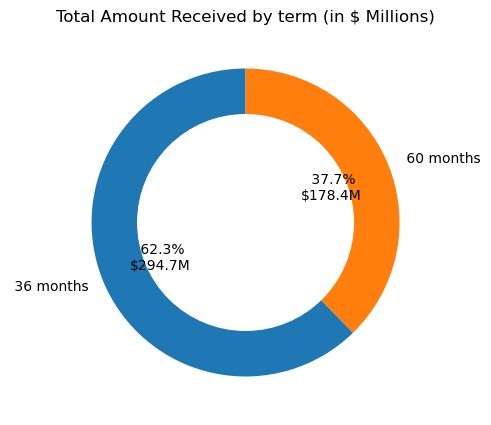

In [61]:
term_amount_received_millions = df.groupby('term')['total_payment'].sum()/1000000

plt.figure(figsize = (5,5))
plt.pie(
    term_amount_received_millions,
    labels = term_amount_received_millions.index,
    autopct = lambda p: f" {p:.1f}%\n${p*sum(term_amount_received_millions)/100:.1f}M",
    startangle = 90,
    wedgeprops = {'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, color = 'white'))
plt.title('Total Amount Received by term (in $ Millions)')
plt.show()

### Long Term Analysis for Total number of Loan Applications

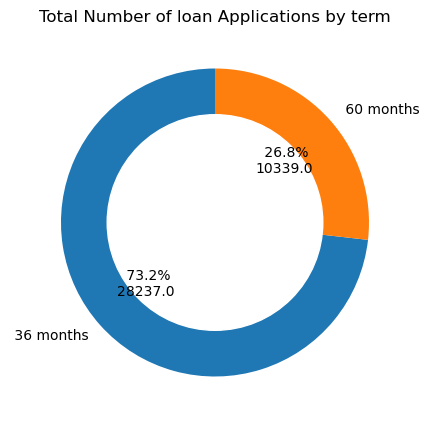

In [64]:
term_loan_applications = df.groupby('term')['id'].count()

plt.figure(figsize = (5,5))
plt.pie(
    term_loan_applications,
    labels = term_loan_applications.index,
    autopct = lambda p: f" {p:.1f}%\n{p*sum(term_loan_applications)/100:.1f}",
    startangle = 90,
    wedgeprops = {'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, color = 'white'))
plt.title('Total Number of loan Applications by term')
plt.show()

### Employee length for Total Funded Amount

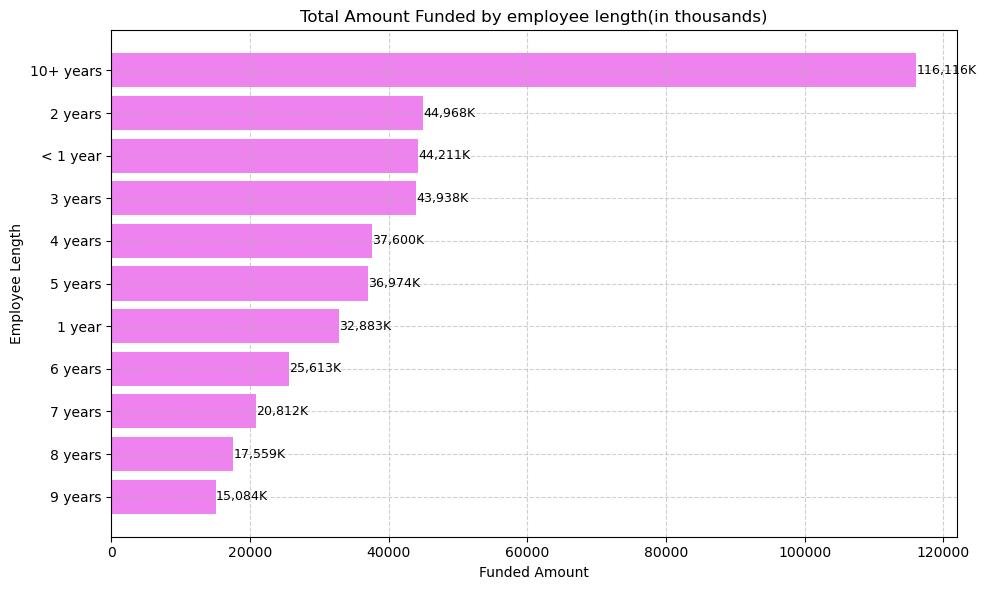

In [27]:
employee_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize = (10,6))
bars = plt.barh(employee_funding.index, employee_funding.values, color = 'violet')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va = 'center', fontsize = 9)

plt.title('Total Amount Funded by employee length(in thousands)')
plt.xlabel('Funded Amount')
plt.ylabel('Employee Length')
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()


### Employee length for Total Amount Received

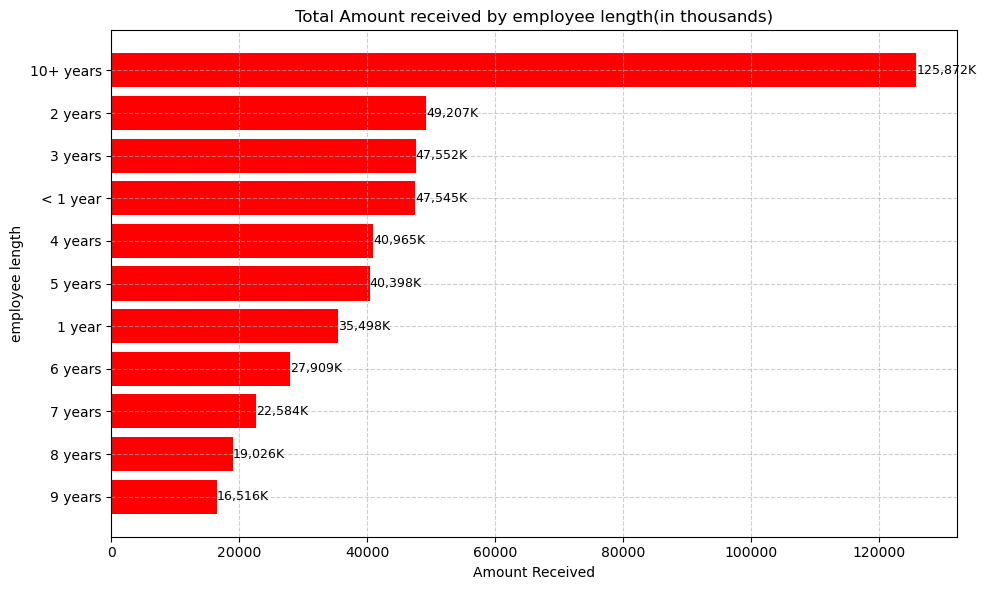

In [32]:
employee_amount_received = df.groupby('emp_length')['total_payment'].sum().sort_values()/1000

plt.figure(figsize = (10,6))
bars = plt.barh(employee_amount_received.index, employee_amount_received.values, color = 'red')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}K', va = 'center', fontsize = 9)

plt.title('Total Amount received by employee length(in thousands)')
plt.xlabel('Amount Received')
plt.ylabel('employee length')
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()


### Employee length for Total loan applications

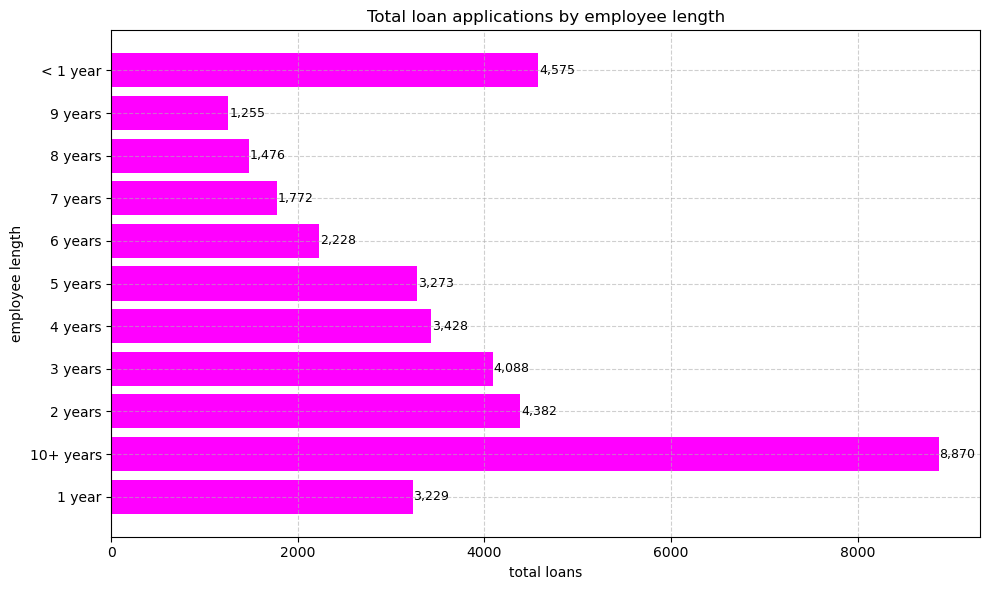

In [31]:
employee_loan_applications = df.groupby('emp_length')['id'].count()

plt.figure(figsize = (10,6))
bars = plt.barh(employee_loan_applications.index, employee_loan_applications.values, color = 'magenta')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}', va = 'center', fontsize = 9)

plt.title('Total loan applications by employee length')
plt.xlabel('total loans')
plt.ylabel('employee length')
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

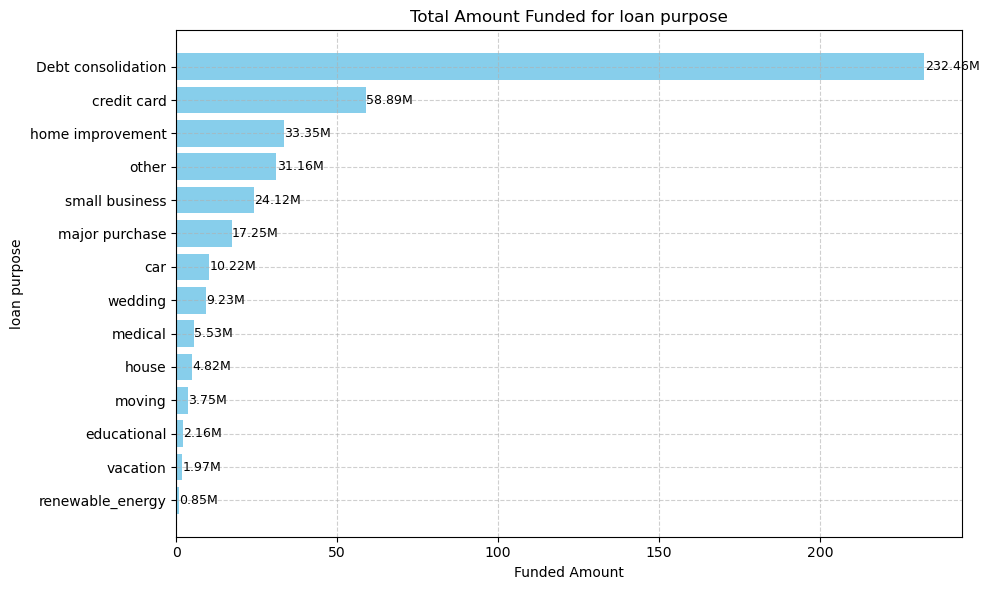

In [30]:
purpose_funding_millions = df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000

plt.figure(figsize = (10,6))
bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color = 'skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2F}M', va = 'center', fontsize = 9)

plt.title('Total Amount Funded for loan purpose')
plt.xlabel('Funded Amount')
plt.ylabel('loan purpose')
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()


### Loan Purpose by Total Amount Received

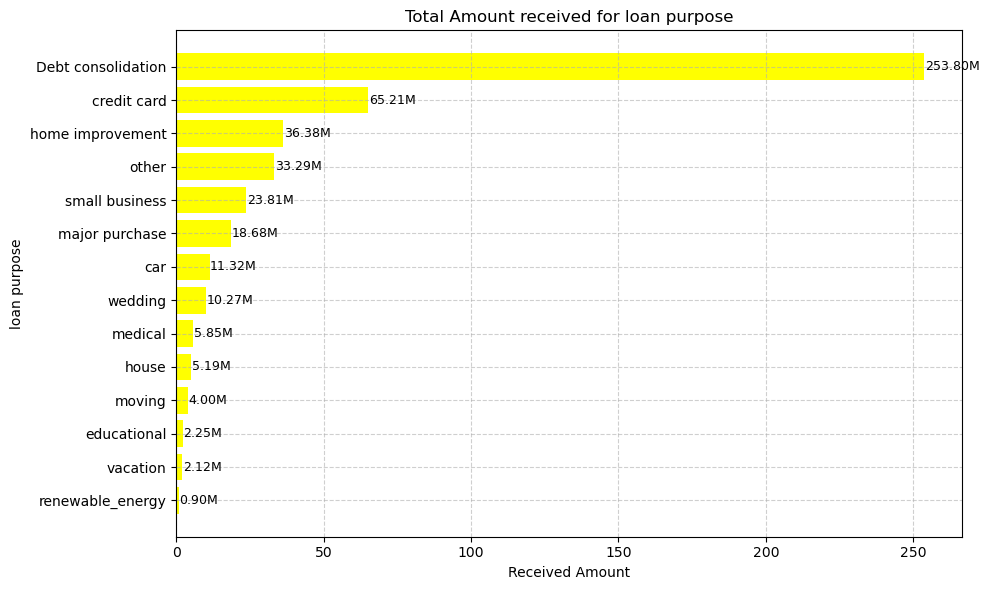

In [29]:
purpose_amount_received_millions = df.groupby('purpose')['total_payment'].sum().sort_values()/1000000

plt.figure(figsize = (10,6))
bars = plt.barh(purpose_amount_received_millions.index,purpose_amount_received_millions.values, color = 'yellow')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2F}M', va = 'center', fontsize = 9)

plt.title('Total Amount received for loan purpose')
plt.xlabel('Received Amount')
plt.ylabel('loan purpose')
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()

### Loan Purpose by Total loan Applications

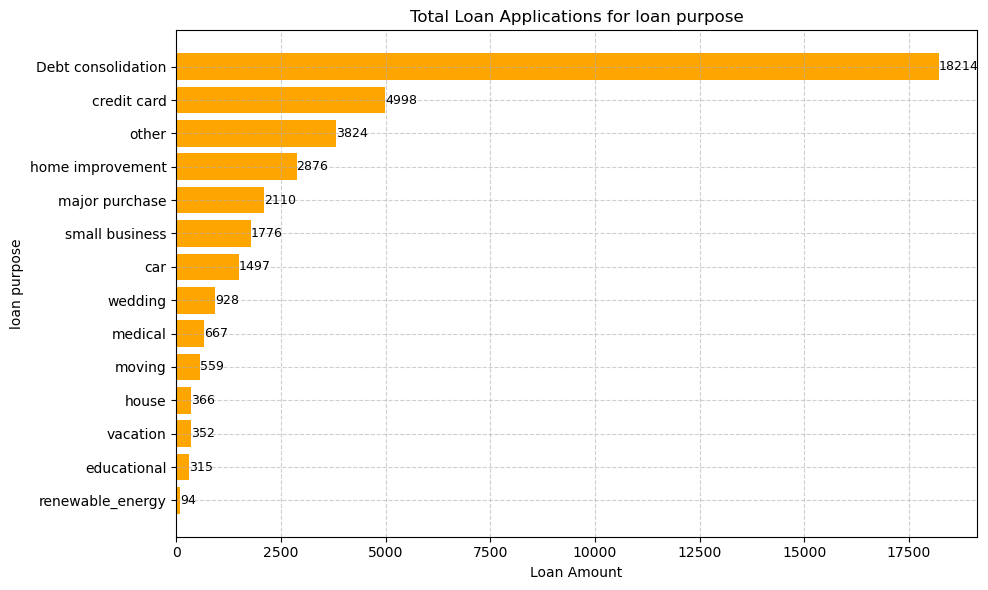

In [28]:
purpose_loan_applications = df.groupby('purpose')['id'].count().sort_values()

plt.figure(figsize = (10,6))
bars = plt.barh(purpose_loan_applications.index,purpose_loan_applications.values, color = 'orange')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.0F}', va = 'center', fontsize = 9)

plt.title('Total Loan Applications for loan purpose')
plt.xlabel('Loan Amount')
plt.ylabel('loan purpose')
plt.grid(True, linestyle = '--', alpha =0.6)
plt.tight_layout()
plt.show()

### Home Ownership for Total Amount Funded

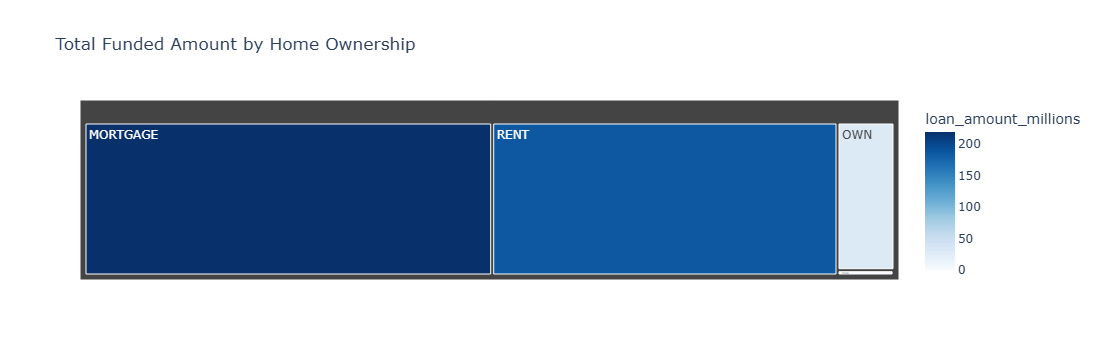

In [38]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1000000

fig = px.treemap(
    home_funding,
    path = ['home_ownership'],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale = 'blues',
    title = 'Total Funded Amount by Home Ownership'
) 
fig.show()


### Home Ownership for Total Amount Received

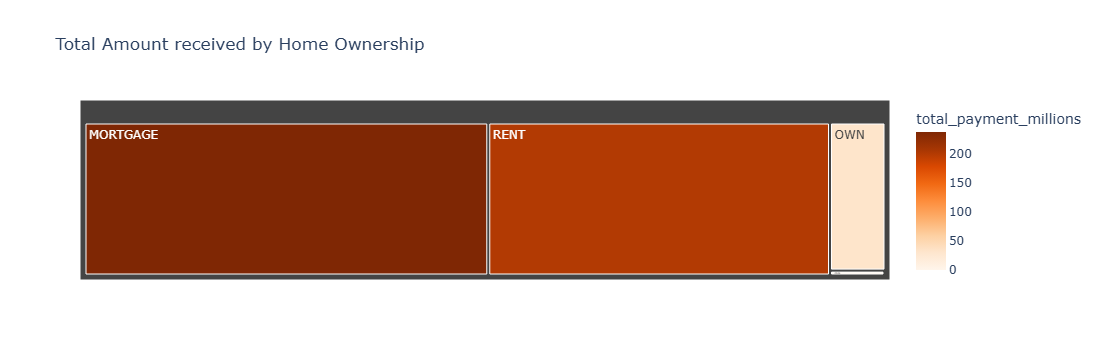

In [45]:
home_amount_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_amount_received['total_payment_millions'] = home_amount_received['total_payment']/1000000

fig = px.treemap(
    home_amount_received,
    path = ['home_ownership'],
    values = 'total_payment_millions',
    color = 'total_payment_millions',
    color_continuous_scale = 'oranges',
    title = 'Total Amount received by Home Ownership'
) 
fig.show()

### Home Ownership for Total loan Applications

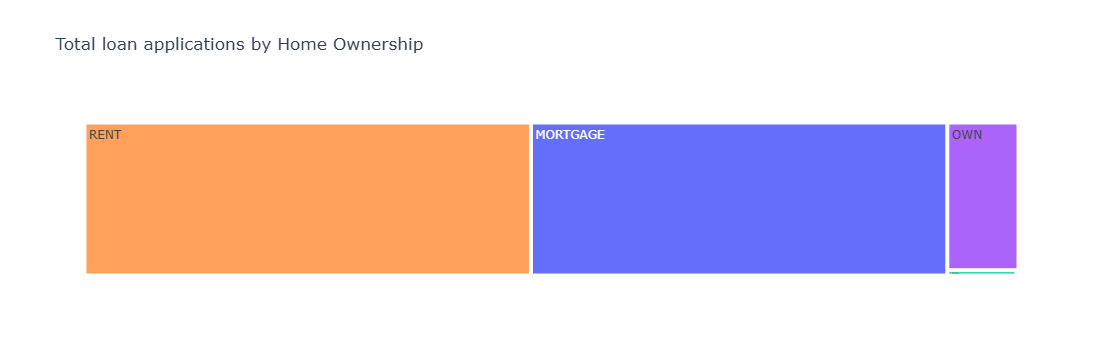

In [49]:
home_loan_applications = df.groupby('home_ownership')['id'].count().reset_index()
#home_amount_received['total_payment_millions'] = home_amount_received['total_payment']/1000000

fig = px.treemap(
    home_loan_applications,
    path = ['home_ownership'],
    values = 'id',
    color = 'id',
    color_continuous_scale = 'oranges',
    title = 'Total loan applications by Home Ownership'
) 
fig.show()